In [1]:
# Install all libraries we need for this project
# Run this only once — you can delete this cell after

!pip install yfinance pandas numpy pandas-ta arch lightgbm \
             optuna shap scikit-learn fastapi uvicorn \
             streamlit plotly mlflow joblib sqlalchemy

  Using cached yfinance-1.4.0-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached pandas_ta-0.4.71b0-py3-none-any.whl.metadata (2.3 kB)
  Using cached arch-8.0.0-cp313-cp313-win_amd64.whl.metadata (13 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached shap-0.51.0-cp313-cp313-win_amd64.whl.metadata (26 kB)
  Using cached fastapi-0.136.3-py3-none-any.whl.metadata (27 kB)
  Using cached mlflow-3.12.0-py3-none-any.whl.metadata (49 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl.metadata (18 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached mlflow_skinny-3.12.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.12.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.2-py3-none-any.whl.metadata (5.3 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.me

In [3]:
# ── Standard library ──────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')   # suppress noisy warnings

# ── Data manipulation ─────────────────────────────────────────
import numpy as np                  # numerical operations
import pandas as pd                 # dataframes — our main data structure

# ── Data collection ───────────────────────────────────────────
import yfinance as yf               # pull free stock data from Yahoo Finance

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt     # base plotting library
import matplotlib.dates as mdates   # format date axis on charts
import seaborn as sns               # prettier statistical plots

# ── Display settings ──────────────────────────────────────────
pd.set_option('display.max_columns', None)   # show all columns in a dataframe
pd.set_option('display.float_format', '{:.4f}'.format)  # 4 decimal places
plt.style.use('seaborn-v0_8-darkgrid')       # cleaner chart style

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [7]:
# ── Define which stocks to track ──────────────────────────────

TICKERS = [
    'RELIANCE.NS',   # Reliance Industries  (NSE)
    'TCS.NS',        # Tata Consultancy     (NSE)
    'HDFCBANK.NS',   # HDFC Bank            (NSE)
    'INFY.NS',       # Infosys              (NSE)
    'SBIN.NS',       # State Bank of India  (NSE)
]

# ── Define date range ─────────────────────────────────────────
START_DATE = '2019-01-01'    # 5 years of data gives enough history
END_DATE   = '2024-12-31'

print(f" Tracking {len(TICKERS)} stocks")
print(f" Date range: {START_DATE} to {END_DATE}")

 Tracking 5 stocks
 Date range: 2019-01-01 to 2024-12-31


In [8]:
# ── Download raw OHLCV data from Yahoo Finance ─────────────────

print("  Downloading data")

raw_data = yf.download(
    tickers    = TICKERS,      # list of stocks defined above
    start      = START_DATE,   # start date
    end        = END_DATE,     # end date
    auto_adjust= True,         # adjusts prices for splits and dividends
    progress   = True          # shows a download progress bar
)

print(f"\n Downloaded successfully!")
print(f" Shape: {raw_data.shape}")   # (rows, columns)
print(f"\n🔍 First 3 rows:")
raw_data.head(3)

[*********************100%***********************]  5 of 5 completed


 Downloaded successfully!
 Shape: (1480, 25)

🔍 First 3 rows:


Price            Close                                                High  \
Ticker     HDFCBANK.NS  INFY.NS RELIANCE.NS  SBIN.NS    TCS.NS HDFCBANK.NS   
2019-01-01    504.3925 553.4485    498.4906 271.5511 1582.1663    505.0735   
2019-01-02    499.7902 556.7772    491.9982 266.3848 1599.2117    504.2516   
2019-01-03    495.8689 556.8604    485.9283 263.8470 1579.7960    499.7315   

Price                                                      Low           \
Ticker      INFY.NS RELIANCE.NS  SBIN.NS    TCS.NS HDFCBANK.NS  INFY.NS   
2019-01-01 554.4888    501.2921 272.5482 1588.1530    494.4132 544.3777   
2019-01-02 560.8966    501.1587 274.1796 1608.4827    497.7239 550.9519   
2019-01-03 563.3931    495.6446 267.8803 1617.2132    493.8026 551.8256   

Price                                            Open                       \
Ticker     RELIANCE.NS  SBIN.NS    TCS.NS HDFCBANK.NS  INFY.NS RELIANCE.NS   
2019-01-01    493.6435 266.3395 1567.3656    499.5907 550.0366    500.3805   
2019-01-02    489.5969 265.6597 1579.8378    503.1480 554.2391    495.6001   
2019-01-03    484.7498 262.9406 1574.1003    498.7805 559.2321    492.4873   

Price                              Volume                                 \
Ticker      SBIN.NS    TCS.NS HDFCBANK.NS  INFY.NS RELIANCE.NS   SBIN.NS   
2019-01-01 269.6477 1576.5121     6373440  2943390     9746670  11837127   
2019-01-02 271.0979 1583.9953     8134232  7416655    15628818  25559853   
2019-01-03 267.3818 1595.6360    12771664  6827249    16288287  17548347   

Price                
Ticker       TCS.NS  
2019-01-01  1094883  
2019-01-02  2100463  
2019-01-03  2611668

In [17]:
# ── Pull only the closing prices ──────────────────────────────
#raw_data['Close'] extracts closing prices — the most important price of the day
# yfinance returns a multi-level column like ('Close', 'TCS.NS')
# We extract just the 'Close' level for simplicity
#.copy() prevents accidental changes to the original download
close_prices = raw_data['Close'].copy()

In [18]:
# ── Check for missing values ───────────────────────────────────
print(" Missing values per stock:")
print(close_prices.isnull().sum())

 Missing values per stock:
Ticker
HDFCBANK.NS    0
INFY.NS        0
RELIANCE.NS    0
SBIN.NS        0
TCS.NS         0
dtype: int64


In [19]:
# Drop any remaining NaN rows at the very start
#removes the very first rows if they still have no price at all
close_prices = close_prices.dropna()

In [20]:
print(f"\n Clean close prices shape: {close_prices.shape}")
print(f"\n Sample data:")
close_prices.head()


 Clean close prices shape: (1480, 5)

 Sample data:


Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,SBIN.NS,TCS.NS
2019-01-01,504.3925,553.4485,498.4906,271.5511,1582.1663
2019-01-02,499.7902,556.7772,491.9982,266.3848,1599.2117
2019-01-03,495.8689,556.8604,485.9283,263.8470,1579.7960
2019-01-04,497.1956,550.1196,488.5519,269.7838,1560.5886
2019-01-07,497.9470,558.9825,491.2645,268.5601,1578.0917


Compute Daily Returns

In [21]:
# Formula: return(t) = (price(t) - price(t-1)) / price(t-1)
# .pct_change() does exactly this in one line
daily_returns = close_prices.pct_change()

In [22]:
# The very first row will be NaN (no previous price exists)
# Drop it cleanly
daily_returns = daily_returns.dropna()

In [23]:
print(f" Returns shape: {daily_returns.shape}")
print(f"\n Sample returns (as decimals, so 0.01 = 1%):")
daily_returns.head()

 Returns shape: (1479, 5)

 Sample returns (as decimals, so 0.01 = 1%):


Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,SBIN.NS,TCS.NS
2019-01-02,-0.0091,0.0060,-0.0130,-0.0190,0.0108
2019-01-03,-0.0078,0.0001,-0.0123,-0.0095,-0.0121
2019-01-04,0.0027,-0.0121,0.0054,0.0225,-0.0122
2019-01-07,0.0015,0.0161,0.0056,-0.0045,0.0112
2019-01-08,-0.0083,-0.0025,-0.0001,0.0304,-0.0023


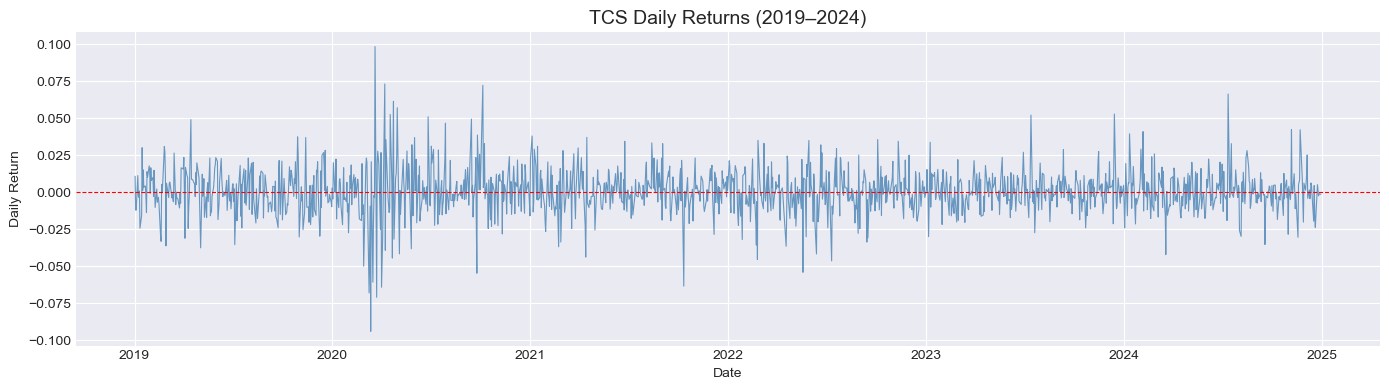

In [28]:
# ─ Visualize returns for one stock 

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(
    daily_returns.index,           # x-axis = dates
    daily_returns['TCS.NS'],       # y-axis = TCS returns
    color='steelblue',
    linewidth=0.8,
    alpha=0.8
)

ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8)  # zero line
ax.set_title('TCS Daily Returns (2019–2024)', fontsize=14)
ax.set_ylabel('Daily Return')
ax.set_xlabel('Date')

#plt.tight_layout() is a function in the Matplotlib library used to automatically adjust subplot parameters so that the subplots, axes labels, and titles fit within the figure area without overlapping.

plt.tight_layout() 
plt.show()

# Compute Realized Volatility (Your Target Variable)

In [29]:
ROLLING_WINDOW = 20    # 20 trading days ≈ 1 calendar month
TRADING_DAYS   = 252   # number of trading days in a year

# Rolling std of returns × √252 to annualize
# This is the TARGET variable your model will learn to predict
realized_vol = (
    daily_returns
    .rolling(window=ROLLING_WINDOW)   # look at last 20 days
    .std()                             # compute standard deviation
    * np.sqrt(TRADING_DAYS)            # annualize it
)

# Drop NaN rows created by the rolling window
realized_vol = realized_vol.dropna()

print(f" Volatility shape: {realized_vol.shape}")
print(f"\n Sample volatility values (0.20 = 20% annualized vol):")
realized_vol.head()

 Volatility shape: (1460, 5)

 Sample volatility values (0.20 = 20% annualized vol):


Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,SBIN.NS,TCS.NS
2019-01-29,0.1066,0.2016,0.2782,0.1959,0.2148
2019-01-30,0.1085,0.2034,0.2776,0.2095,0.2126
2019-01-31,0.1368,0.2257,0.2813,0.2215,0.2122
2019-02-01,0.1378,0.2155,0.2848,0.2331,0.2049
2019-02-04,0.1402,0.2149,0.2994,0.2330,0.2044


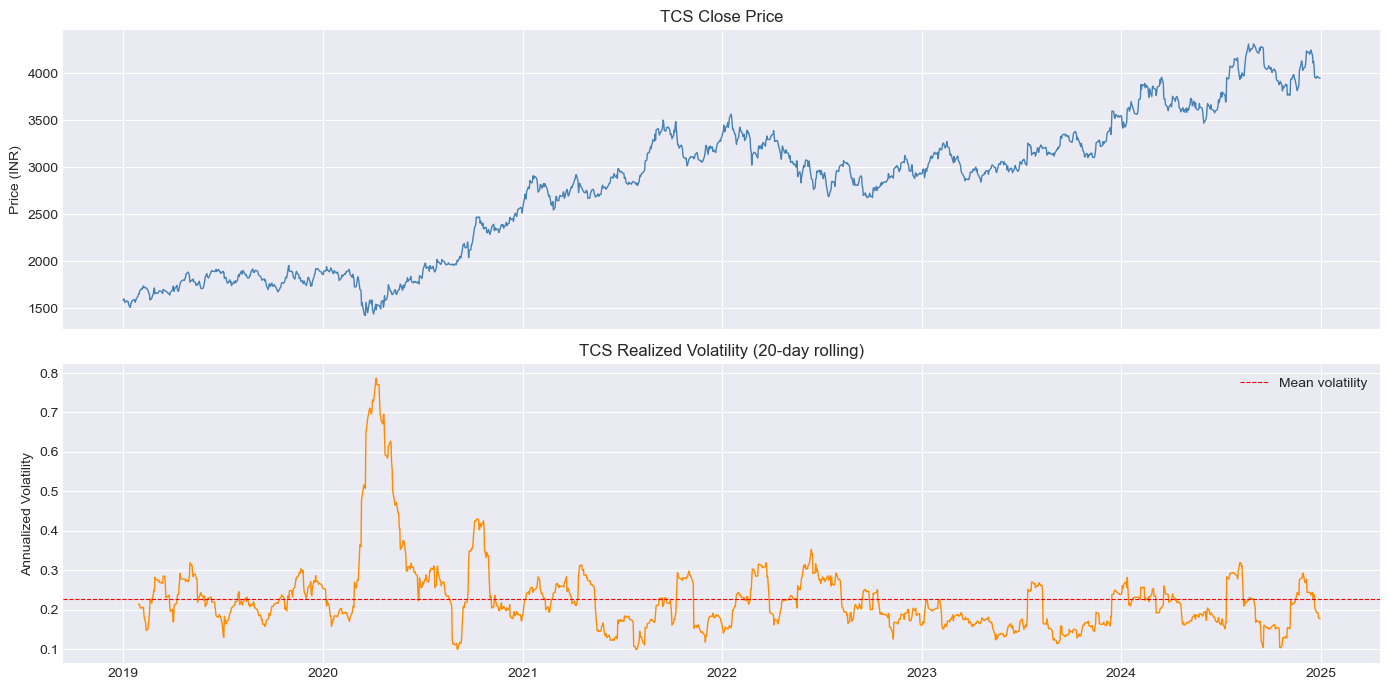

In [35]:
# ─ Visualize volatility for one stock 

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
#In Python, the sharex=True argument  forces multiple subplots to share the same horizontal X-axis.

# Top chart — close price
axes[0].plot(close_prices.index, close_prices['TCS.NS'],
             color='steelblue', linewidth=1)
axes[0].set_title('TCS Close Price', fontsize=12)
axes[0].set_ylabel('Price (INR)')

# Bottom chart — realized volatility
axes[1].plot(realized_vol.index, realized_vol['TCS.NS'],
             color='darkorange', linewidth=1)
axes[1].axhline(y=realized_vol['TCS.NS'].mean(),
                color='red', linestyle='--', linewidth=0.8,
                label='Mean volatility')
axes[1].set_title('TCS Realized Volatility (20-day rolling)', fontsize=12)
axes[1].set_ylabel('Annualized Volatility')
axes[1].legend()
# adds a legend box to the second subplot (index 1) of a figure. 
#This box explains what each plotted line, bar, or marker represents by mapping them to the label= tags you assigned during plotting.

plt.tight_layout()
plt.show()
#A value of 0.30 means the stock is moving at ~30% annualized volatility

# Save Data To Disk 

In [36]:
import os

# ── Your base project path ────────────────────────────────────
BASE_PATH = r"E:\ML\End-to-End Stock Volatility Forecasting System"

# ── Create subfolders inside your project folder ──────────────
os.makedirs(f"{BASE_PATH}/data/raw",       exist_ok=True)
os.makedirs(f"{BASE_PATH}/data/processed", exist_ok=True)

# ── Save files ────────────────────────────────────────────────
close_prices.to_csv(f"{BASE_PATH}/data/raw/close_prices.csv")
daily_returns.to_csv(f"{BASE_PATH}/data/processed/daily_returns.csv")
realized_vol.to_csv(f"{BASE_PATH}/data/processed/realized_volatility.csv")

print(" Files saved successfully!")
print(f" {BASE_PATH}\\data\\raw\\close_prices.csv")
print(f" {BASE_PATH}\\data\\processed\\daily_returns.csv")
print(f" {BASE_PATH}\\data\\processed\\realized_volatility.csv")

 Files saved successfully!
 E:\ML\End-to-End Stock Volatility Forecasting System\data\raw\close_prices.csv
 E:\ML\End-to-End Stock Volatility Forecasting System\data\processed\daily_returns.csv
 E:\ML\End-to-End Stock Volatility Forecasting System\data\processed\realized_volatility.csv


In [39]:
print("=" * 40)
print("PHASE 1 SUMMARY")
print("=" * 40)
print(f"Stocks       : {list(close_prices.columns)}") #f means this is an f-string (allows expressions inside {})
print(f"Date range   : {close_prices.index[0].date()} → {close_prices.index[-1].date()}")
print(f"Trading days : {len(close_prices)}")
print(f"Avg TCS vol  : {realized_vol['TCS.NS'].mean():.2%}") # .2 show 2 decimal value
print(f"Max TCS vol  : {realized_vol['TCS.NS'].max():.2%}  ← likely COVID spike")
print("=" * 40)

PHASE 1 SUMMARY
Stocks       : ['HDFCBANK.NS', 'INFY.NS', 'RELIANCE.NS', 'SBIN.NS', 'TCS.NS']
Date range   : 2019-01-01 → 2024-12-30
Trading days : 1480
Avg TCS vol  : 22.65%
Max TCS vol  : 78.73%  ← likely COVID spike


# Feature Engineering

In [40]:
# ─Load saved CSVs 
close_prices = pd.read_csv(
    f"{BASE_PATH}/data/raw/close_prices.csv",
    index_col=0,        # first column is the date index
    parse_dates=True    # convert date strings to datetime objects
)

daily_returns = pd.read_csv(
    f"{BASE_PATH}/data/processed/daily_returns.csv",
    index_col=0,
    parse_dates=True
)

realized_vol = pd.read_csv(
    f"{BASE_PATH}/data/processed/realized_volatility.csv",
    index_col=0,
    parse_dates=True
)

print(" All files loaded!")
print(f" Close prices : {close_prices.shape}")
print(f" Returns      : {daily_returns.shape}")
print(f" Volatility   : {realized_vol.shape}")

 All files loaded!
 Close prices : (1480, 5)
 Returns      : (1479, 5)
 Volatility   : (1460, 5)


Features we will build 

Feature Group         What it captures


Lagged volatility   → "Was it volatile yesterday/last week?"

Lagged returns      → "Which direction was it moving?"

Rolling stats       → "What's the short/long term vol trend?"

RSI                 → "Is the stock overbought or oversold?"

Volume features     → "Is unusual activity happening?"

Day of week         → "Are Mondays more volatile than Fridays?"

In [46]:
# ── Pick one stock to work with first 
STOCK = 'TCS.NS'

# ── Create a clean working dataframe
df = pd.DataFrame(index=daily_returns.index)

# Add the three base series for this stock
df['close']   = close_prices[STOCK]
df['returns'] = daily_returns[STOCK]
df['vol']     = realized_vol[STOCK]    # this is our TARGET (y)

print(f" Base dataframe for {STOCK}:")
print(f"Shape: {df.shape}")
df.head()

 Base dataframe for TCS.NS:
Shape: (1479, 3)


,close,returns,vol
2019-01-02,1599.2117,0.0108,NaN
2019-01-03,1579.7960,-0.0121,NaN
2019-01-04,1560.5886,-0.0122,NaN
2019-01-07,1578.0917,0.0112,NaN
2019-01-08,1574.4749,-0.0023,NaN


In [47]:
df

,close,returns,vol
2019-01-02,1599.2117,0.0108,NaN
2019-01-03,1579.7960,-0.0121,NaN
2019-01-04,1560.5886,-0.0122,NaN
2019-01-07,1578.0917,0.0112,NaN
2019-01-08,1574.4749,-0.0023,NaN
...,...,...,...
2024-12-23,3946.7700,-0.0029,0.1945
2024-12-24,3966.8914,0.0051,0.1923
2024-12-26,3957.0210,-0.0025,0.1921
2024-12-27,3952.9873,-0.0010,0.1794


In [50]:
# ── Lagged volatility features 
# "What was volatility 1 day ago, 5 days ago, 10 days ago?"
# This is the most powerful feature for predicting volatility

LAG_DAYS = [1, 2, 3, 5, 10, 20]   # lag periods to create

for lag in LAG_DAYS:
    col_name = f'vol_lag_{lag}'          # e.g. 'vol_lag_1', 'vol_lag_5'
    df[col_name] = df['vol'].shift(lag)  # shift pushes values down by `lag` rows
#.shift(1) moves every value down by 1 row — so row 5 now has row 4's value

print(" Lagged volatility features added:")
print([c for c in df.columns if 'vol_lag' in c])
df[['vol', 'vol_lag_1', 'vol_lag_5', 'vol_lag_20']].head(25).tail(5)

 Lagged volatility features added:
['vol_lag_1', 'vol_lag_2', 'vol_lag_3', 'vol_lag_5', 'vol_lag_10', 'vol_lag_20']


,vol,vol_lag_1,vol_lag_5,vol_lag_20
2019-01-30,0.2126,0.2148,NaN,NaN
2019-01-31,0.2122,0.2126,NaN,NaN
2019-02-01,0.2049,0.2122,NaN,NaN
2019-02-04,0.2044,0.2049,NaN,NaN
2019-02-05,0.2046,0.2044,0.2148,NaN


In [52]:
# ── Lagged return features ─
# "What was the return yesterday, 2 days ago, last week?"
# Captures momentum and direction

RETURN_LAGS = [1, 2, 3, 5]

for lag in RETURN_LAGS:
    col_name = f'return_lag_{lag}'
    df[col_name] = df['returns'].shift(lag)

print("✅ Lagged return features added:")
print([c for c in df.columns if 'return_lag' in c])
df.head()

✅ Lagged return features added:
['return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5']


,close,returns,vol,vol_lag_1,vol_lag_2,vol_lag_3,vol_lag_5,vol_lag_10,vol_lag_20,return_lag_1,return_lag_2,return_lag_3,return_lag_5
2019-01-02,1599.2117,0.0108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,1579.7960,-0.0121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0108,NaN,NaN,NaN
2019-01-04,1560.5886,-0.0122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0121,0.0108,NaN,NaN
2019-01-07,1578.0917,0.0112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0122,-0.0121,0.0108,NaN
2019-01-08,1574.4749,-0.0023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0112,-0.0122,-0.0121,NaN


In [57]:
# ── Rolling mean of volatility 
# "What is the average volatility over the last 5/10/20 days?"
# Captures the short and long term volatility trend

ROLL_WINDOWS = [5, 10, 20, 60]    # 1 week, 2 weeks, 1 month, 3 months

for window in ROLL_WINDOWS:
    # Rolling mean — smooth trend of volatility
    df[f'vol_roll_mean_{window}'] = (
        df['vol']
        .shift(1)              # shift FIRST to avoid leakage
        .rolling(window)       # then compute rolling window
        .mean()
    )

    # Rolling std of volatility — "is volatility itself volatile?"
    df[f'vol_roll_std_{window}'] = (
        df['vol']
        .shift(1)
        .rolling(window)
        .std()
    )

print(" Rolling stats features added:")
print([c for c in df.columns if 'roll' in c])
df.head()
#We always .shift(1) before .rolling() — this is very important
#Without shift, the rolling window includes today's value which is leakage

 Rolling stats features added:
['vol_roll_mean_5', 'vol_roll_std_5', 'vol_roll_mean_10', 'vol_roll_std_10', 'vol_roll_mean_20', 'vol_roll_std_20', 'vol_roll_mean_60', 'vol_roll_std_60']


,close,returns,vol,vol_lag_1,vol_lag_2,vol_lag_3,vol_lag_5,vol_lag_10,vol_lag_20,return_lag_1,return_lag_2,return_lag_3,return_lag_5,vol_roll_mean_5,vol_roll_std_5,vol_roll_mean_10,vol_roll_std_10,vol_roll_mean_20,vol_roll_std_20,vol_roll_mean_60,vol_roll_std_60
2019-01-02,1599.2117,0.0108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,1579.7960,-0.0121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-04,1560.5886,-0.0122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0121,0.0108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-07,1578.0917,0.0112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0122,-0.0121,0.0108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-08,1574.4749,-0.0023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0112,-0.0122,-0.0121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
# ── RSI — Relative Strength Index 
# RSI measures if a stock is overbought (>70) or oversold (<30)
# Range: 0 to 100
# Formula: RSI = 100 - (100 / (1 + avg_gain/avg_loss))

def compute_rsi(price_series, window=14):
    """
    Computes RSI for a given price series.
    
    Args:
        price_series : pandas Series of closing prices
        window       : lookback period (14 is industry standard)
    
    Returns:
        pandas Series of RSI values
    """
    # Step 1 — compute daily price change
    delta = price_series.diff()          # today - yesterday

    # Step 2 — separate gains and losses
    gain = delta.clip(lower=0)           # keep only positive changes lower 0 set negative value to 0
    loss = -delta.clip(upper=0)          # keep only negative changes (flip sign)

    # Step 3 — compute rolling average of gains and losses
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    # Step 4 — compute RS and then RSI
    rs  = avg_gain / avg_loss            # relative strength ratio
    rsi = 100 - (100 / (1 + rs))        # scale to 0-100

    return rsi

# Apply RSI to close prices and shift to avoid leakage
df['rsi_14'] = compute_rsi(df['close'], window=14).shift(1)

print(" RSI feature added")
print(f"RSI range: {df['rsi_14'].min():.1f} to {df['rsi_14'].max():.1f}")

 RSI feature added
RSI range: 7.3 to 97.3


In [60]:
df.tail()

,close,returns,vol,vol_lag_1,vol_lag_2,vol_lag_3,vol_lag_5,vol_lag_10,vol_lag_20,return_lag_1,return_lag_2,return_lag_3,return_lag_5,vol_roll_mean_5,vol_roll_std_5,vol_roll_mean_10,vol_roll_std_10,vol_roll_mean_20,vol_roll_std_20,vol_roll_mean_60,vol_roll_std_60,rsi_14
2024-12-23,3946.7700,-0.0029,0.1945,0.2050,0.2380,0.2266,0.2441,0.2437,0.2794,-0.0238,-0.0175,0.0045,-0.0131,0.2281,0.0149,0.2352,0.0126,0.2552,0.0243,0.1963,0.0563,41.5063
2024-12-24,3966.8914,0.0051,0.1923,0.1945,0.2050,0.2380,0.2267,0.2449,0.2800,-0.0029,-0.0238,-0.0175,-0.0196,0.2182,0.0178,0.2303,0.0176,0.2510,0.0271,0.1970,0.0561,38.1975
2024-12-26,3957.0210,-0.0025,0.1921,0.1923,0.1945,0.2050,0.2266,0.2430,0.2809,0.0051,-0.0029,-0.0238,0.0045,0.2113,0.0202,0.2250,0.0204,0.2466,0.0292,0.1976,0.0558,34.9612
2024-12-27,3952.9873,-0.0010,0.1794,0.1921,0.1923,0.1945,0.2380,0.2430,0.2921,-0.0025,0.0051,-0.0029,-0.0175,0.2044,0.0195,0.2199,0.0217,0.2421,0.0304,0.1983,0.0555,19.4195
2024-12-30,3947.2444,-0.0015,0.1774,0.1794,0.1921,0.1923,0.2050,0.2371,0.2924,-0.0010,-0.0025,0.0051,-0.0238,0.1927,0.0091,0.2136,0.0234,0.2365,0.0311,0.1987,0.0552,20.0129


In [62]:
# ── Volume features 
# High unusual volume often precedes high volatility
# We don't use raw volume — we normalize it as a z-score

import yfinance as yf

# Re-download volume data (we didn't save it in Phase 1)
raw_data = yf.download(
    tickers     = [STOCK],
    start       = '2019-01-01',
    end         = '2024-12-31',
    auto_adjust = True,
    progress    = False
)

volume = raw_data['Volume'].squeeze()  # .squeeze() converts a single-column DataFrame into a Series
volume.index = pd.to_datetime(volume.index)

# Align volume index with our dataframe
volume = volume.reindex(df.index)

# Volume z-score = (today's volume - 20day avg) / 20day std
# Values above 2 = unusually high volume
vol_mean_20 = volume.shift(1).rolling(20).mean()
vol_std_20  = volume.shift(1).rolling(20).std()

df['volume_zscore'] = (volume - vol_mean_20) / vol_std_20

print(" Volume z-score feature added")
print(f"Sample values: {df['volume_zscore'].dropna().head(3).values}")

 Volume z-score feature added
Sample values: [-0.35216258  0.49812693 -0.07218828]


In [63]:
# ── Calendar / time features
# Markets behave differently on different days
# Monday often has higher volatility (weekend news effect)

df['day_of_week'] = df.index.dayofweek    
# 0=Monday, 1=Tuesday, ..., 4=Friday

df['month'] = df.index.month             
# 1=January ... 12=December

df['quarter'] = df.index.quarter         
# 1, 2, 3, or 4

# Is it the first or last week of the month?
# Options expiry happens last Thursday — increases volatility
df['week_of_month'] = (df.index.day - 1) // 7 + 1   
# 1=first week, 2=second week, etc.

print(" Calendar features added")
print(df[['day_of_week', 'month', 'quarter', 'week_of_month']].head())

 Calendar features added
            day_of_week  month  quarter  week_of_month
2019-01-02            2      1        1              1
2019-01-03            3      1        1              1
2019-01-04            4      1        1              1
2019-01-07            0      1        1              1
2019-01-08            1      1        1              2


In [66]:
# ── Create the target variable ────────────────────────────────
# We want to predict TOMORROW's volatility
# So we shift volatility BACKWARD by 1 (into the future)

df['target'] = df['vol'].shift(-1)
# shift(-1) means: "bring tomorrow's value to today's row"
# So on row for date 2020-01-05, target = vol on 2020-01-06

print(" Target variable created")
print("\nVerification — last column should be next day's vol:")
df[['vol', 'target']].head(10)


 Target variable created

Verification — last column should be next day's vol:


,vol,target
2019-01-02,NaN,NaN
2019-01-03,NaN,NaN
2019-01-04,NaN,NaN
2019-01-07,NaN,NaN
2019-01-08,NaN,NaN
2019-01-09,NaN,NaN
2019-01-10,NaN,NaN
2019-01-11,NaN,NaN
2019-01-14,NaN,NaN
2019-01-15,NaN,NaN


In [67]:
# ── Drop rows with NaN values 
# NaNs exist at the start (due to rolling windows) 
# and at the very end (due to target shift)

df_clean = df.dropna()

print(f" Shape before dropping NaN : {df.shape}")
print(f" Shape after dropping NaN  : {df_clean.shape}")
print(f" Rows dropped              : {df.shape[0] - df_clean.shape[0]}")

print(f"\n All features ({len(df_clean.columns)} total):")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i:2}. {col}")

 Shape before dropping NaN : (1479, 28)
 Shape after dropping NaN  : (1399, 28)
 Rows dropped              : 80

 All features (28 total):
   1. close
   2. returns
   3. vol
   4. vol_lag_1
   5. vol_lag_2
   6. vol_lag_3
   7. vol_lag_5
   8. vol_lag_10
   9. vol_lag_20
  10. return_lag_1
  11. return_lag_2
  12. return_lag_3
  13. return_lag_5
  14. vol_roll_mean_5
  15. vol_roll_std_5
  16. vol_roll_mean_10
  17. vol_roll_std_10
  18. vol_roll_mean_20
  19. vol_roll_std_20
  20. vol_roll_mean_60
  21. vol_roll_std_60
  22. rsi_14
  23. volume_zscore
  24. day_of_week
  25. month
  26. quarter
  27. week_of_month
  28. target


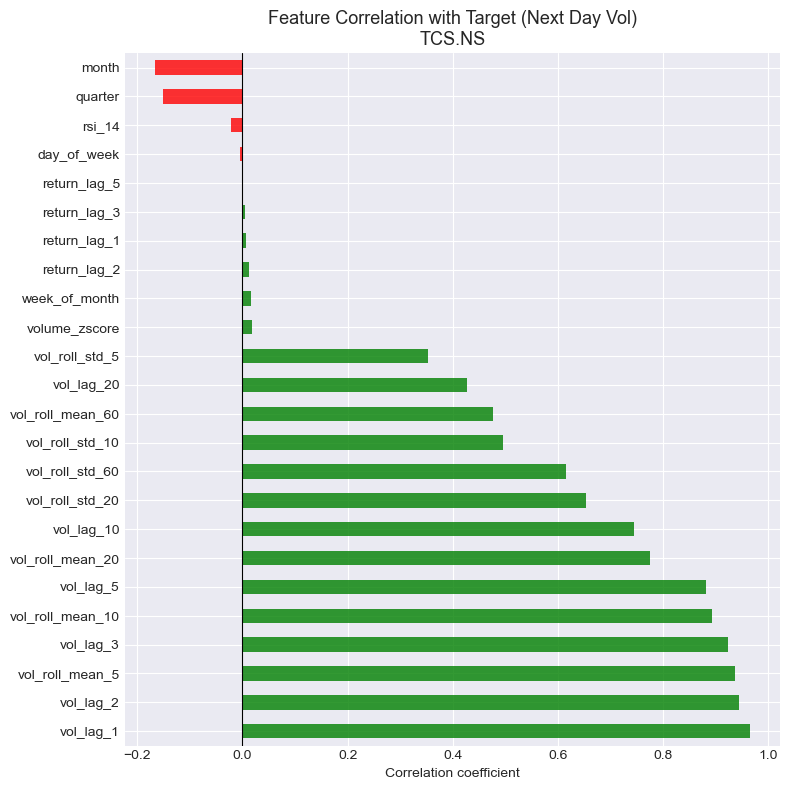

In [68]:
# ── Correlation heatmap
# Shows which features are most related to the target

# Select only feature columns (exclude raw close and returns)
feature_cols = [c for c in df_clean.columns 
                if c not in ['close', 'returns', 'vol']]

corr = df_clean[feature_cols].corr()['target'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))

corr.drop('target').plot(
    kind   = 'barh',       # horizontal bar chart
    ax     = ax,
    color  = ['green' if x > 0 else 'red' for x in corr.drop('target')],
    alpha  = 0.8
)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title(f'Feature Correlation with Target (Next Day Vol)\n{STOCK}', 
             fontsize=13)
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

In [69]:
# ── Save the feature dataframe ────────────────────────────────
os.makedirs(f"{BASE_PATH}/data/features", exist_ok=True)

save_path = f"{BASE_PATH}/data/features/features_{STOCK.replace('.', '_')}.csv"
df_clean.to_csv(save_path)

print(f" Features saved!")
print(f" {save_path}")
print(f"\n Final dataset: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f" Date range   : {df_clean.index[0].date()} → {df_clean.index[-1].date()}")
print(f" Target column: 'target' = next day's realized volatility")

 Features saved!
 E:\ML\End-to-End Stock Volatility Forecasting System/data/features/features_TCS_NS.csv

 Final dataset: 1399 rows × 28 columns
 Date range   : 2019-05-03 → 2024-12-27
 Target column: 'target' = next day's realized volatility


# Model evaluation


In [71]:
# ── Define feature columns (X) and target column (y) ──────────

# X = everything the model is ALLOWED to see (inputs)
# y = what the model needs to PREDICT (output)

# Drop columns that are not features
X = df.drop(columns=['close', 'returns', 'vol', 'target'])

# Target = next day's volatility
y = df['target']

print(f" X shape (features) : {X.shape}")
print(f" y shape (target)   : {y.shape}")
print(f"\n Feature columns ({len(X.columns)}):")
print(list(X.columns))

 X shape (features) : (1479, 24)
 y shape (target)   : (1479,)

 Feature columns (24):
['vol_lag_1', 'vol_lag_2', 'vol_lag_3', 'vol_lag_5', 'vol_lag_10', 'vol_lag_20', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'vol_roll_mean_5', 'vol_roll_std_5', 'vol_roll_mean_10', 'vol_roll_std_10', 'vol_roll_mean_20', 'vol_roll_std_20', 'vol_roll_mean_60', 'vol_roll_std_60', 'rsi_14', 'volume_zscore', 'day_of_week', 'month', 'quarter', 'week_of_month']


In [72]:
# ── Walk-forward train/test split
# NEVER use random train_test_split on time series
# We must always train on past and test on future

# Use 80% data for training, last 20% for testing
split_idx = int(len(df) * 0.80)

X_train = X.iloc[:split_idx]    # first 80% rows
X_test  = X.iloc[split_idx:]    # last  20% rows

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f" Total samples  : {len(df)}")
print(f"  Train samples  : {len(X_train)}  ({X_train.index[0].date()} → {X_train.index[-1].date()})")
print(f" Test samples   : {len(X_test)}   ({X_test.index[0].date()}  → {X_test.index[-1].date()})")

 Total samples  : 1479
  Train samples  : 1183  (2019-01-02 → 2023-10-13)
 Test samples   : 296   (2023-10-16  → 2024-12-30)


In [73]:
#  Train GARCH Model (Baseline)
from arch import arch_model

# ── GARCH needs raw returns, not our feature dataframe ─────────
# Use the training period returns for fitting

returns_train = df['returns'].iloc[:split_idx] * 100
# multiply by 100 because arch library works better with percentages
# so 0.015 (1.5%) becomes 1.5

# ── Define and fit the GARCH(1,1) model ───────────────────────
garch_model = arch_model(
    returns_train,
    vol   = 'Garch',   # use GARCH volatility model
    p     = 1,         # lag order for past volatility (standard = 1)
    q     = 1,         # lag order for past shocks     (standard = 1)
    dist  = 'normal'   # assume returns follow normal distribution
)

garch_fit = garch_model.fit(
    disp = 'off'       # disp='off' silences the verbose output
)

print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2126.69
Distribution:                  Normal   AIC:                           4261.39
Method:            Maximum Likelihood   BIC:                           4281.69
                                        No. Observations:                 1183
Date:                Sun, May 24 2026   Df Residuals:                     1182
Time:                        14:04:35   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0742  4.008e-02      1.852  6.403e-02 [-4.32

In [74]:
# ── Generate GARCH forecasts for test period ──────────────────

returns_full = df['returns'] * 100   # full returns series

# We generate one-step-ahead forecasts using a rolling window
# For each day in test set, refit on all past data and predict next day

garch_preds = []

print(" Generating GARCH forecasts ")

for i in range(len(X_test)):

    # Use all data up to current test point
    train_end   = split_idx + i
    returns_sub = returns_full.iloc[:train_end]

    # Fit GARCH on this expanding window
    model = arch_model(returns_sub, vol='Garch', p=1, q=1, dist='normal')
    fit   = model.fit(disp='off', show_warning=False)

    # Forecast 1 step ahead
    forecast    = fit.forecast(horizon=1)
    variance    = forecast.variance.values[-1, 0]   # predicted variance
    volatility  = np.sqrt(variance) * np.sqrt(252) / 100
    # convert: variance → std dev → annualized → back from percentage

    garch_preds.append(volatility)

# Convert to Series with same index as test set
garch_preds = pd.Series(garch_preds, index=X_test.index)

print(f" GARCH forecasts generated: {len(garch_preds)} predictions")

 Generating GARCH forecasts 
 GARCH forecasts generated: 296 predictions


In [75]:
#Train LightGBM Model
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# ── Define LightGBM parameters ────────────────────────────────
lgb_params = {
    'objective'       : 'regression',   # we are predicting a number (not a class)
    'metric'          : 'mae',           # optimize Mean Absolute Error
    'n_estimators'    : 500,             # number of trees to build
    'learning_rate'   : 0.05,            # how much each tree corrects the last
    'num_leaves'      : 31,              # complexity of each tree (default=31)
    'min_child_samples': 20,             # minimum data points per leaf
    'subsample'       : 0.8,             # use 80% of rows per tree (reduces overfitting)
    'colsample_bytree': 0.8,             # use 80% of features per tree
    'random_state'    : 42,              # for reproducibility
    'verbose'         : -1               # silence training output
}

# ── Create and train the model ────────────────────────────────
lgb_model = lgb.LGBMRegressor(**lgb_params)
# **lgb_params unpacks the dictionary as keyword arguments

lgb_model.fit(
    X_train, y_train,

    eval_set              = [(X_test, y_test)],
    # monitor performance on test set during training

    callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]
    # stop training if test score doesn't improve for 50 rounds
    # prevents overfitting
)

print(f" LightGBM trained!")
print(f" Trees built : {lgb_model.best_iteration_}")

 LightGBM trained!
 Trees built : 43


In [76]:
# ── Generate LightGBM predictions on test set ─────────────────
lgb_preds = lgb_model.predict(X_test)

# Convert to pandas Series for easier plotting
lgb_preds = pd.Series(lgb_preds, index=X_test.index)

print(f" LightGBM predictions generated: {len(lgb_preds)}")
print(f"\nSample predictions:")
print(lgb_preds.head())

 LightGBM predictions generated: 296

Sample predictions:
2023-10-16   0.1497
2023-10-17   0.1523
2023-10-18   0.1508
2023-10-19   0.1520
2023-10-20   0.1486
dtype: float64


Evaluating Both Models

In [79]:
# ── Check where NaNs are ──────────────────────────────────────
print(f"NaNs in garch_preds : {garch_preds.isna().sum()}")
print(f"NaNs in lgb_preds   : {lgb_preds.isna().sum()}")
print(f"NaNs in y_test      : {y_test.isna().sum()}")

print(f"\nTotal test samples  : {len(y_test)}")

NaNs in garch_preds : 0
NaNs in lgb_preds   : 0
NaNs in y_test      : 1

Total test samples  : 296


In [81]:
# ── Align garch_preds, lgb_preds, and y_test on same index ────

# Combine all three into one dataframe
eval_df = pd.DataFrame({
    'actual'    : y_test,
    'garch_pred': garch_preds,
    'lgb_pred'  : lgb_preds
})

# Drop ANY row where any value is NaN
eval_df = eval_df.dropna()

print(f" Rows after dropping NaN : {len(eval_df)}")
print(f"  Rows dropped            : {len(y_test) - len(eval_df)}")
print(eval_df.head())

 Rows after dropping NaN : 295
  Rows dropped            : 1
            actual  garch_pred  lgb_pred
2023-10-16  0.1329      0.1964    0.1497
2023-10-17  0.1332      0.2020    0.1523
2023-10-18  0.1341      0.1971    0.1508
2023-10-19  0.1411      0.1935    0.1520
2023-10-20  0.1609      0.1910    0.1486


In [87]:
# ── Evaluate using cleaned aligned data ───────────────────────
# ── Compute evaluation metrics ────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error
def evaluate_model(name, actual, predicted):
    """
    Prints MAE, RMSE, and MAPE for a model.
    
    Args:
        name      : string label for the model
        actual    : true volatility values (y_test)
        predicted : model's predicted values
    """
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    # MAPE = Mean Absolute Percentage Error

    print(f"\n{'─'*35}")
    print(f"  Model : {name}")
    print(f"{'─'*35}")
    print(f"  MAE   : {mae:.4f}   (lower is better)")
    print(f"  RMSE  : {rmse:.4f}  (lower is better)")
    print(f"  MAPE  : {mape:.2f}%  (lower is better)")
    print(f"{'─'*35}")

    return {'mae': mae, 'rmse': rmse, 'mape': mape}
    
garch_metrics = evaluate_model(
    'GARCH(1,1)',
    eval_df['actual'],
    eval_df['garch_pred']
)

lgb_metrics = evaluate_model(
    'LightGBM',
    eval_df['actual'],
    eval_df['lgb_pred']
)

# ── Compare improvement ───────────────────────────────────────
improvement = (garch_metrics['mae'] - lgb_metrics['mae']) / garch_metrics['mae'] * 100
print(f"\n LightGBM improved MAE by {improvement:.1f}% over GARCH")


───────────────────────────────────
  Model : GARCH(1,1)
───────────────────────────────────
  MAE   : 0.0312   (lower is better)
  RMSE  : 0.0373  (lower is better)
  MAPE  : 17.15%  (lower is better)
───────────────────────────────────

───────────────────────────────────
  Model : LightGBM
───────────────────────────────────
  MAE   : 0.0147   (lower is better)
  RMSE  : 0.0211  (lower is better)
  MAPE  : 7.75%  (lower is better)
───────────────────────────────────

 LightGBM improved MAE by 52.8% over GARCH


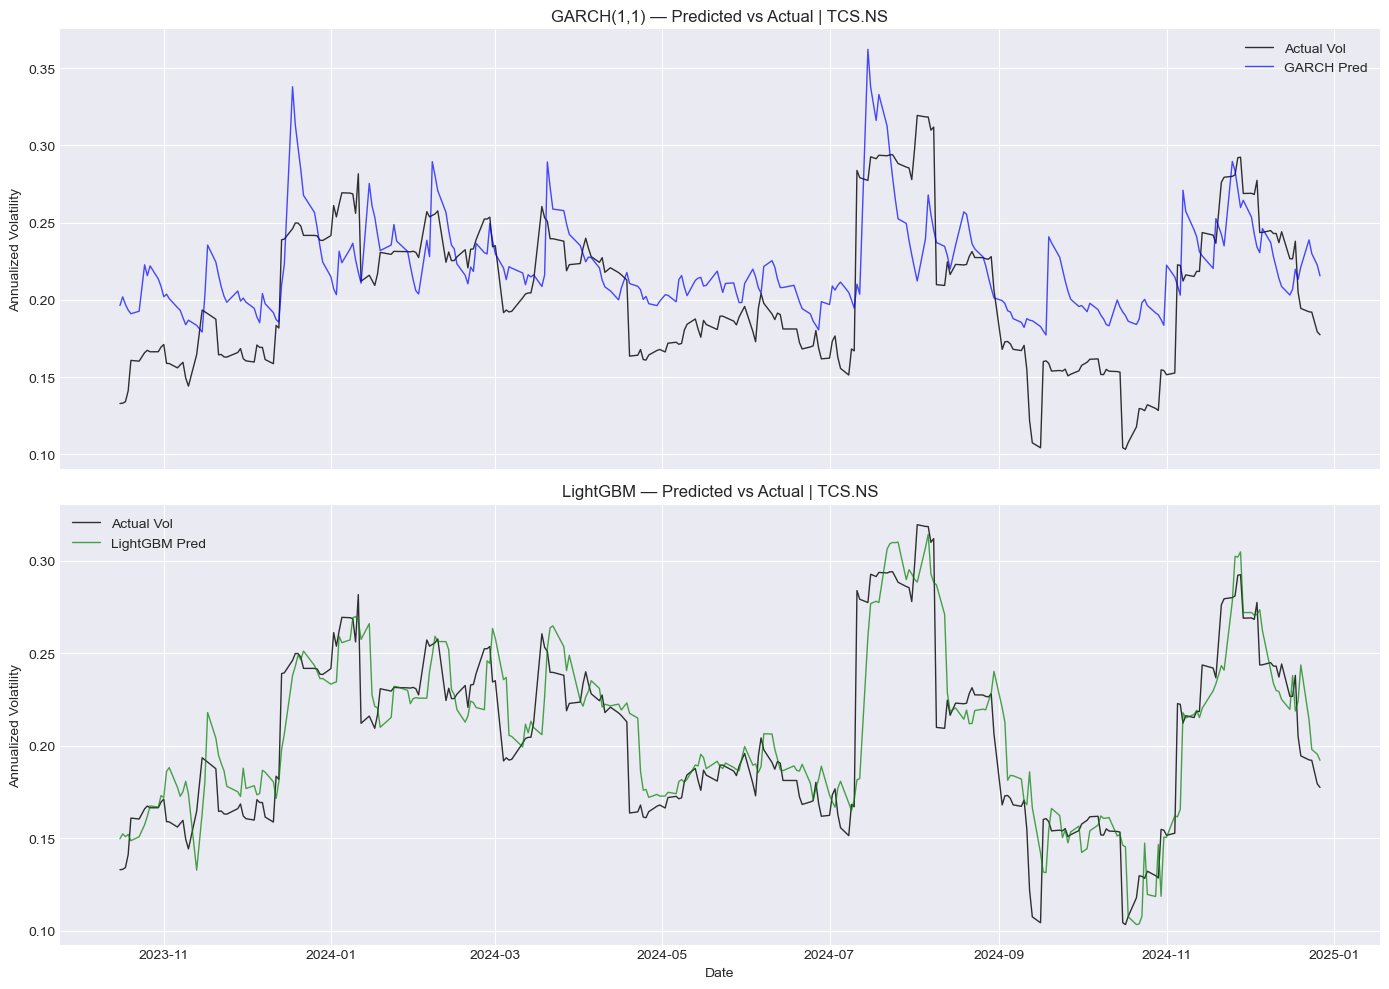

In [88]:
# ── Which features did LightGBM find most useful?

importance_df = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': lgb_model.feature_importances_
})
# feature_importances_ = how many times each feature was used to split trees

importance_df = importance_df.sort_values('importance', ascending=True)
# ascending=True so most important appears at top of horizontal bar chart

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ── Top chart — GARCH ─────────────────────────────────────────
axes[0].plot(eval_df.index, eval_df['actual'],
             color='black',  linewidth=1, label='Actual Vol', alpha=0.8)
axes[0].plot(eval_df.index, eval_df['garch_pred'],
             color='blue',   linewidth=1, label='GARCH Pred', alpha=0.7)
axes[0].set_title(f'GARCH(1,1) — Predicted vs Actual | {STOCK}', fontsize=12)
axes[0].set_ylabel('Annualized Volatility')
axes[0].legend()

# ── Bottom chart — LightGBM ───────────────────────────────────
axes[1].plot(eval_df.index, eval_df['actual'],
             color='black',  linewidth=1, label='Actual Vol',    alpha=0.8)
axes[1].plot(eval_df.index, eval_df['lgb_pred'],
             color='green',  linewidth=1, label='LightGBM Pred', alpha=0.7)
axes[1].set_title(f'LightGBM — Predicted vs Actual | {STOCK}', fontsize=12)
axes[1].set_ylabel('Annualized Volatility')
axes[1].legend()

plt.xlabel('Date')
plt.tight_layout()
plt.show()

In [89]:
import joblib

# ── Create models folder ──────────────────────────────────────
os.makedirs(f"{BASE_PATH}/models", exist_ok=True)

# ── Save LightGBM model ───────────────────────────────────────
lgb_path = f"{BASE_PATH}/models/lgb_model_{STOCK.replace('.', '_')}.pkl"
joblib.dump(lgb_model, lgb_path)
# joblib.dump = serialize and save python object to disk

# ── Save predictions for Phase 4 ─────────────────────────────
os.makedirs(f"{BASE_PATH}/data/predictions", exist_ok=True)

preds_df = pd.DataFrame({
    'actual'      : y_test,
    'garch_pred'  : garch_preds,
    'lgb_pred'    : lgb_preds
})

preds_df.to_csv(f"{BASE_PATH}/data/predictions/test_predictions_{STOCK.replace('.','_')}.csv")

print(" Models and predictions saved!")
print(f" {lgb_path}")

 Models and predictions saved!
 E:\ML\End-to-End Stock Volatility Forecasting System/models/lgb_model_TCS_NS.pkl


# Deployment

In [102]:
import os

BASE_PATH = r"E:\ML\End-to-End Stock Volatility Forecasting System"

# ── Create all required folders ───────────────────────────────
folders = [
    f"{BASE_PATH}/app",
    f"{BASE_PATH}/models",
    f"{BASE_PATH}/data/predictions"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f" Created : {folder}")

 Created : E:\ML\End-to-End Stock Volatility Forecasting System/app
 Created : E:\ML\End-to-End Stock Volatility Forecasting System/models
 Created : E:\ML\End-to-End Stock Volatility Forecasting System/data/predictions


In [103]:
# ── Check model was saved correctly in Phase 3 ────────────────
model_path = f"{BASE_PATH}/models/lgb_model_TCS_NS.pkl"

if os.path.exists(model_path):
    print(f" Model found : {model_path}")
else:
    print(f" Model NOT found at : {model_path}")
    print("\n  You need to re-run Phase 3 Step 11 to save the model")
    print("Look for this line in Phase 3:")
    print("   joblib.dump(lgb_model, lgb_path)")

 Model found : E:\ML\End-to-End Stock Volatility Forecasting System/models/lgb_model_TCS_NS.pkl


In [106]:
app_path       = f"{BASE_PATH}/app"
predictor_path = f"{app_path}/predictor.py"

predictor_code = '''\
import os
import joblib
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

BASE_PATH = r"E:\\ML\\End-to-End Stock Volatility Forecasting System"

# ── RSI helper ────────────────────────────────────────────────
def compute_rsi(price_series, window=14):
    delta    = price_series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs       = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

# ── Main prediction function ──────────────────────────────────
def predict_volatility(ticker: str) -> dict:

    # Download last 120 days of data
    raw = yf.download(
        ticker,
        period      = "120d",
        auto_adjust = True,
        progress    = False
    )

    if raw.empty:
        return {"error": f"No data found for {ticker}"}

    # Base series
    close   = raw["Close"].squeeze()
    returns = close.pct_change().dropna()
    vol     = returns.rolling(20).std() * np.sqrt(252)

    # Feature dataframe
    df = pd.DataFrame(index=returns.index)
    df["close"]   = close
    df["returns"] = returns
    df["vol"]     = vol

    # Lagged volatility
    for lag in [1, 2, 3, 5, 10, 20]:
        df[f"vol_lag_{lag}"] = df["vol"].shift(lag)

    # Lagged returns
    for lag in [1, 2, 3, 5]:
        df[f"return_lag_{lag}"] = df["returns"].shift(lag)

    # Rolling stats
    for window in [5, 10, 20, 60]:
        df[f"vol_roll_mean_{window}"] = df["vol"].shift(1).rolling(window).mean()
        df[f"vol_roll_std_{window}"]  = df["vol"].shift(1).rolling(window).std()

    # RSI
    df["rsi_14"] = compute_rsi(df["close"], window=14).shift(1)

    # Volume z-score
    volume              = raw["Volume"].squeeze().reindex(df.index)
    vol_mean            = volume.shift(1).rolling(20).mean()
    vol_std             = volume.shift(1).rolling(20).std()
    df["volume_zscore"] = (volume - vol_mean) / vol_std

    # Calendar features
    df["day_of_week"]   = df.index.dayofweek
    df["month"]         = df.index.month
    df["quarter"]       = df.index.quarter
    df["week_of_month"] = (df.index.day - 1) // 7 + 1

    # Drop NaN rows
    df = df.dropna()

    if df.empty:
        return {"error": "Not enough data to generate features"}

    # Load saved model
    model_path = os.path.join(
        BASE_PATH, "models",
        f"lgb_model_{ticker.replace(\'.\', \'_\')}.pkl"
    )

    if not os.path.exists(model_path):
        return {"error": f"No trained model found for {ticker}"}

    model = joblib.load(model_path)

    # Build feature row
    feature_cols = [c for c in df.columns
                    if c not in ["close", "returns", "vol"]]

    X_latest   = df[feature_cols].iloc[[-1]]
    prediction = model.predict(X_latest)[0]

    return {
        "ticker"           : ticker,
        "prediction_date"  : str(df.index[-1].date()),
        "predicted_vol"    : round(float(prediction), 4),
        "predicted_vol_pct": f"{prediction:.2%}",
        "current_vol"      : round(float(df["vol"].iloc[-1]), 4),
        "current_price"    : round(float(close.iloc[-1]), 2),
        "rsi"              : round(float(df["rsi_14"].iloc[-1]), 2),
        "risk_level"       : "High"   if prediction > 0.30 else
                             "Medium" if prediction > 0.15 else "Low"
    }
'''

with open(predictor_path, "w", encoding="utf-8") as f:
    f.write(predictor_code)

print(f" predictor.py saved!")
print(f" {predictor_path}")
print(f" File size : {os.path.getsize(predictor_path)} bytes")

 predictor.py saved!
 E:\ML\End-to-End Stock Volatility Forecasting System/app/predictor.py
 File size : 3678 bytes


In [108]:
api_path = f"{app_path}/api.py"

api_code = '''\
import sys
import os
sys.path.insert(0, os.path.dirname(__file__))

from fastapi import FastAPI, HTTPException
from predictor import predict_volatility
import uvicorn

app = FastAPI(
    title       = "Stock Volatility Forecaster",
    description = "Predicts next-day annualized volatility using LightGBM",
    version     = "1.0.0"
)

@app.get("/")
def root():
    return {
        "status" : "running",
        "message": "Volatility Forecaster API is live"
    }

@app.get("/predict/{ticker}")
def get_prediction(ticker: str):
    result = predict_volatility(ticker.upper())
    if "error" in result:
        raise HTTPException(status_code=400, detail=result["error"])
    return result

@app.get("/compare")
def compare_stocks(tickers: str = "TCS.NS,INFY.NS,HDFCBANK.NS"):
    ticker_list = [t.strip() for t in tickers.split(",")]
    results = []
    for ticker in ticker_list:
        pred = predict_volatility(ticker)
        if "error" not in pred:
            results.append(pred)
    results = sorted(results, key=lambda x: x["predicted_vol"], reverse=True)
    return {"count": len(results), "stocks": results}

if __name__ == "__main__":
    uvicorn.run("api:app", host="0.0.0.0", port=8000, reload=True)
'''

with open(api_path, "w") as f:
    f.write(api_code)

print(f" api.py saved!")
print(f" {api_path}")

 api.py saved!
 E:\ML\End-to-End Stock Volatility Forecasting System/app/api.py


In [110]:
dashboard_path = f"{app_path}/dashboard.py"

dashboard_code = '''\
import sys
import os
sys.path.insert(0, os.path.dirname(__file__))

import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import yfinance as yf
from predictor import predict_volatility

BASE_PATH = r"E:\\ML\\End-to-End Stock Volatility Forecasting System"

st.set_page_config(
    page_title = "Volatility Forecaster",
    page_icon  = "📈",
    layout     = "wide"
)

st.title("📈 Stock Volatility Forecasting Dashboard")
st.markdown("*Predicts next-day annualized volatility using LightGBM*")
st.divider()

# ── Sidebar ───────────────────────────────────────────────────
st.sidebar.header("⚙️ Settings")

AVAILABLE_STOCKS = {
    "TCS"       : "TCS.NS",
    "Reliance"  : "RELIANCE.NS",
    "HDFC Bank" : "HDFCBANK.NS",
    "Infosys"   : "INFY.NS",
    "State Bank": "SBIN.NS"
}

selected_name   = st.sidebar.selectbox(
    "Select Stock",
    options = list(AVAILABLE_STOCKS.keys())
)
selected_ticker = AVAILABLE_STOCKS[selected_name]

lookback_days = st.sidebar.slider(
    "Lookback Period (days)",
    min_value = 30,
    max_value = 365,
    value     = 120,
    step      = 10
)

st.sidebar.divider()
st.sidebar.info("Models trained on NSE data 2019-2024")

# ── Prediction ────────────────────────────────────────────────
with st.spinner(f"Fetching prediction for {selected_name}..."):
    result = predict_volatility(selected_ticker)

if "error" in result:
    st.error(f"❌ {result[\'error\']}")
    st.stop()

# ── Metric cards ──────────────────────────────────────────────
st.subheader(f"📊 {selected_name} ({selected_ticker})")

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric("Predicted Volatility", result["predicted_vol_pct"])
with col2:
    st.metric("Current Volatility",   f"{result[\'current_vol\']:.2%}")
with col3:
    st.metric("Current Price",        f"₹{result[\'current_price\']:,.2f}")
with col4:
    risk  = result["risk_level"]
    icon  = "🔴" if risk == "High" else "🟡" if risk == "Medium" else "🟢"
    st.metric("Risk Level", f"{icon} {risk}")

st.divider()

# ── Charts ────────────────────────────────────────────────────
st.subheader("📉 Historical Price & Volatility")

raw     = yf.download(selected_ticker, period=f"{lookback_days}d",
                      auto_adjust=True, progress=False)
close   = raw["Close"].squeeze()
returns = close.pct_change().dropna()
vol     = returns.rolling(20).std() * np.sqrt(252)

chart_col1, chart_col2 = st.columns(2)

with chart_col1:
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=close.index, y=close.values,
        mode="lines", name="Close Price",
        line=dict(color="steelblue", width=1.5)
    ))
    fig.update_layout(title=f"{selected_name} Close Price",
                      xaxis_title="Date", yaxis_title="Price (INR)", height=350)
    st.plotly_chart(fig, use_container_width=True)

with chart_col2:
    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(
        x=vol.index, y=vol.values,
        mode="lines", name="Realized Vol",
        line=dict(color="darkorange", width=1.5),
        fill="tozeroy", fillcolor="rgba(255,165,0,0.1)"
    ))
    fig2.add_hline(
        y=result["predicted_vol"], line_dash="dash", line_color="red",
        annotation_text=f"Predicted: {result[\'predicted_vol_pct\']}"
    )
    fig2.update_layout(title=f"{selected_name} Realized Volatility",
                       xaxis_title="Date", yaxis_title="Ann. Volatility", height=350)
    st.plotly_chart(fig2, use_container_width=True)

st.divider()

# ── Multi stock comparison ────────────────────────────────────
st.subheader("🔍 Multi-Stock Risk Comparison")

with st.spinner("Loading all stocks..."):
    comparison = []
    for name, ticker in AVAILABLE_STOCKS.items():
        pred = predict_volatility(ticker)
        if "error" not in pred:
            comparison.append({
                "Stock"         : name,
                "Ticker"        : ticker,
                "Predicted Vol" : pred["predicted_vol_pct"],
                "Current Price" : f"₹{pred[\'current_price\']:,.2f}",
                "RSI"           : pred["rsi"],
                "Risk Level"    : pred["risk_level"]
            })

comp_df = pd.DataFrame(comparison)

fig3 = px.bar(
    comp_df, x="Stock",
    y=[float(v.strip("%"))/100 for v in comp_df["Predicted Vol"]],
    color="Risk Level",
    color_discrete_map={"High":"#ff4444","Medium":"#ffaa00","Low":"#44bb44"},
    title="Predicted Next-Day Volatility by Stock",
    labels={"y": "Predicted Volatility"}
)
st.plotly_chart(fig3, use_container_width=True)

st.dataframe(comp_df, use_container_width=True, hide_index=True)

st.divider()
st.caption("Built with LightGBM + GARCH | Data: Yahoo Finance | NSE Stocks")
'''

with open(dashboard_path, "w", encoding="utf-8") as f:
    f.write(dashboard_code)

print(f" dashboard.py saved!")
print(f" {dashboard_path}")

 dashboard.py saved!
 E:\ML\End-to-End Stock Volatility Forecasting System/app/dashboard.py


In [111]:
print(" Verifying app folder contents:\n")

for filename in ["predictor.py", "api.py", "dashboard.py"]:
    full_path = f"{app_path}/{filename}"
    exists    = os.path.exists(full_path)
    size      = os.path.getsize(full_path) if exists else 0
    status    = "✅" if exists else "❌"
    print(f"  {status} {filename:20s} — {size} bytes")

 Verifying app folder contents:

  ✅ predictor.py         — 3678 bytes
  ✅ api.py               — 1260 bytes
  ✅ dashboard.py         — 5387 bytes


In [112]:
import sys

# Add app folder to Python path
if app_path not in sys.path:
    sys.path.insert(0, app_path)

# Import and test
from predictor import predict_volatility

print(" Testing predictor for TCS.NS ...\n")
result = predict_volatility("TCS.NS")

for key, value in result.items():
    print(f"  {key:20s} : {value}")

 Testing predictor for TCS.NS ...

  ticker               : TCS.NS
  prediction_date      : 2026-05-22
  predicted_vol        : 0.2566
  predicted_vol_pct    : 25.66%
  current_vol          : 0.2113
  current_price        : 2317.3
  rsi                  : 27.48
  risk_level           : Medium


In [113]:
BASE_PATH = r"E:\ML\End-to-End Stock Volatility Forecasting System"

gitignore_content = """\
# Python
__pycache__/
*.py[cod]
*.pyo
.ipynb_checkpoints/

# Data files (too large for GitHub)
data/raw/
data/processed/
data/predictions/

# Trained model files (too large)
models/

# Environment
.env
*.egg-info/

# OS files
.DS_Store
Thumbs.db
"""

with open(f"{BASE_PATH}/.gitignore", "w") as f:
    f.write(gitignore_content)

print(" .gitignore saved!")

 .gitignore saved!
